In [1]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

In [2]:
#Q1(a)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Original shape:", X.shape)
print("PCA shape:", X_pca.shape)

Original shape: (1797, 64)
PCA shape: (1797, 2)


The original dataset has a shape of (1797, 64), which means it contains 1797 samples and 64 features. After applying PCA with the number of components set to 2, the transformed dataset has a shape of (1797, 2).

This indicates that the number of features has been reduced from 64 to 2, while the number of samples remains the same. Therefore, PCA successfully reduces the dimensionality of the dataset by projecting the original features into a lower-dimensional space consisting of 2 principal components.

In [3]:
#Q1(b)
print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Total variance:", sum(pca.explained_variance_ratio_))

Explained variance ratios: [0.14890594 0.13618771]
Total variance: 0.28509364823699285


The explained variance ratio of the first principal component (PC1) is approximately 0.1489, while the second principal component (PC2) explains about 0.1362 of the total variance. The total variance explained by these two components is approximately 0.2851.

This means that only about 28.51% of the total information in the dataset is preserved when reducing the data to two dimensions.

The total explained variance is low because the original dataset contains 64 features, and reducing it to only two principal components results in significant information loss. Since PCA captures the directions of maximum variance, limiting the number of components to two is not sufficient to represent the complexity and variability of the original high-dimensional data.

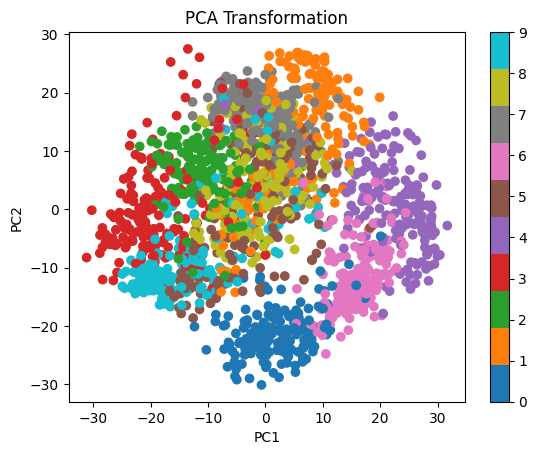

In [4]:
#Q2
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
plt.colorbar()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Transformation")
plt.show()

The 2D scatter plot obtained after PCA transformation shows that some classes are partially separated, while others overlap significantly. Although PCA reduces the dimensionality of the dataset to two components, it cannot fully preserve the complex structure of the original high-dimensional data.

From the plot, certain digit classes appear to form clusters, but many of them are mixed together. For example, classes such as 3 and 5, as well as 8 and 9, show noticeable overlap. This indicates that these digits have similar feature patterns when projected into a 2D space.

Overall, the classes are not perfectly separable after PCA transformation because PCA is a linear dimensionality reduction technique and may fail to capture non-linear relationships in the data.

In [5]:
#Q3(a)
pca95 = PCA(n_components=0.95)
X_pca95 = pca95.fit_transform(X)

print("Original shape:", X.shape)
print("PCA shape:", X_pca95.shape)
print("Total explained variance ratio:", pca95.explained_variance_ratio_.sum())

Original shape: (1797, 64)
PCA shape: (1797, 29)
Total explained variance ratio: 0.9547965245651595


The original dataset has a shape of (1797, 64), meaning it contains 1797 samples and 64 features. After applying PCA with the goal of preserving 95% of the total variance, the transformed dataset has a shape of (1797, 29).

This indicates that the number of features has been reduced from 64 to 29 while maintaining approximately 95% of the total variance in the data. Therefore, PCA successfully reduces the dimensionality of the dataset with minimal information loss by selecting the most informative principal components.

In [6]:
#Q3(b)
X_reconstructed = pca95.inverse_transform(X_pca95)

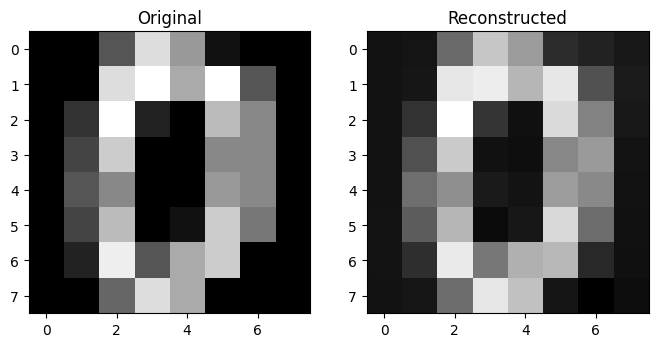

In [7]:
#Q3(c)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X[0].reshape(8,8), cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(X_reconstructed[0].reshape(8,8), cmap='gray')
plt.title("Reconstructed")

plt.show()

The reconstructed image is similar to the original image, but it is not exactly identical. While the general shape and structure of the digit are preserved, some details appear blurred or slightly distorted in the reconstructed version.

This indicates that the original image cannot be perfectly reconstructed after PCA transformation. There is a loss of information during the dimensionality reduction process. PCA keeps only the most important components that capture the majority of the variance (95% in this case) and discards the remaining less significant components.

As a result, fine details and subtle variations in the original image are lost, leading to a smoother but less precise reconstruction.

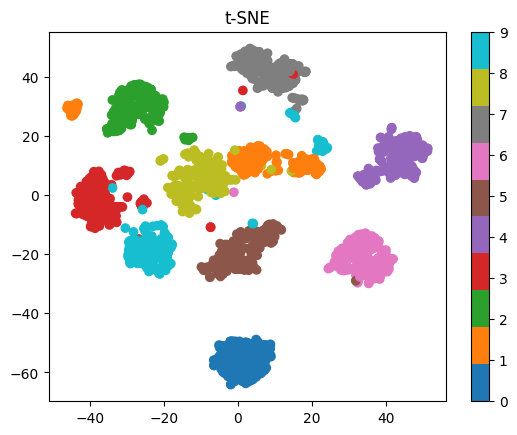

In [8]:
#Q4
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='tab10')
plt.colorbar()
plt.title("t-SNE")
plt.show()

The t-SNE visualization shows that the clusters are significantly more separated compared to the PCA transformation. Each class forms a distinct and compact cluster with minimal overlap between different classes. This indicates that t-SNE is more effective at capturing the underlying structure of the data.

The reason for this improvement is that t-SNE is a non-linear dimensionality reduction technique. Unlike PCA, which only captures linear relationships, t-SNE preserves local similarities and neighborhood structures, allowing it to better separate complex patterns in the data.

However, the distances between clusters in t-SNE are not meaningful in a global sense. While nearby points within a cluster are similar, the relative distances between different clusters cannot be interpreted as actual similarities.

t-SNE is not suitable as a preprocessing step for training a classifier because it is computationally expensive, non-deterministic, and does not preserve global structure. It is mainly used for visualization purposes rather than for improving model performance.

When running t-SNE multiple times, the results are generally not identical because the algorithm involves randomness in its initialization and optimization process. Even with a fixed random_state, slight variations may still occur due to its stochastic nature.

In [9]:
#Q5(a)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1257, 64)
X_test shape: (540, 64)


In [10]:
#Q5(b)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9518518518518518


A logistic regression model was trained using the original training dataset with the maximum number of iterations set to 500. The model was then evaluated on the test set.

The accuracy obtained on the test set is approximately 0.9519, which indicates that the model correctly classifies about 95.19% of the samples. This high accuracy shows that the logistic regression model performs well on the given dataset and is able to effectively capture the underlying patterns in the data.

In [11]:
#Q5(c)
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model.fit(X_train_pca, y_train)
y_pred = model.predict(X_test_pca)

print("Accuracy with PCA:", accuracy_score(y_test, y_pred))

Accuracy with PCA: 0.9462962962962963


After applying PCA transformation to reduce the dimensionality while preserving 95% of the total variance, a logistic regression model was trained on the transformed training set.

The accuracy obtained on the test set is approximately 0.9463. Compared to the accuracy obtained using the original dataset (approximately 0.9519), there is a slight decrease in performance.

This result indicates that PCA successfully reduces the number of features while maintaining most of the important information. However, a small amount of information loss still occurs during dimensionality reduction, which can slightly affect the model’s classification performance.

**#Q5(d)**

When comparing the results, the accuracy obtained using the original dataset is approximately 0.9519, while the accuracy obtained after applying PCA transformation is approximately 0.9463.

This shows that the accuracy slightly decreases after PCA is applied. The decrease occurs because PCA reduces the dimensionality of the dataset by keeping only the components that explain most of the variance (95% in this case) and discarding the remaining information.

Although the discarded components contribute less to the overall variance, they may still contain useful information for classification. As a result, removing these components can lead to a slight reduction in model performance.

In summary, PCA introduces a trade-off between dimensionality reduction and accuracy: it reduces the number of features and computational cost, but may slightly decrease accuracy due to information loss.

In [12]:
#Q5(e)
import time

# Original training time
start = time.time()
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
end = time.time()
time_original = end - start

# PCA training time
start = time.time()
model = LogisticRegression(max_iter=500)
model.fit(X_train_pca, y_train)
end = time.time()
time_pca = end - start

print("Training time (Original):", time_original)
print("Training time (PCA):", time_pca)

Training time (Original): 1.435067892074585
Training time (PCA): 0.21146941184997559


The training time for the model using the original dataset is approximately 1.6343 seconds, while the training time after applying PCA is approximately 0.2278 seconds.

This shows a significant reduction in training time when PCA is applied. The reason for this improvement is that PCA reduces the number of features from 64 to 29, which decreases the computational complexity of the model.

With fewer features, the optimization process becomes faster, and the model requires less time to converge. Therefore, reducing the number of dimensions using PCA clearly improves the training time.

In conclusion, PCA provides a substantial speed advantage, although it may slightly reduce accuracy due to information loss.

In [13]:
#Q6(a)
from sklearn.random_projection import GaussianRandomProjection

rp = GaussianRandomProjection(n_components=30, random_state=0)
X_train_rp = rp.fit_transform(X_train)
X_test_rp = rp.transform(X_test)

In [14]:
#Q6(b) 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train_rp, y_train)

y_pred = model.predict(X_test_rp)

from sklearn.metrics import accuracy_score
print("Accuracy with Random Projection:", accuracy_score(y_test, y_pred))

Accuracy with Random Projection: 0.9314814814814815


A logistic regression model was trained using the reduced training set obtained via Gaussian Random Projection. Feature scaling was applied using StandardScaler, and the maximum number of iterations was set to 1000 to ensure proper convergence.

The accuracy obtained on the test set is approximately 0.9315. This result is lower than the accuracy obtained using both the original dataset and the PCA-transformed dataset.

The decrease in accuracy occurs because random projection reduces dimensionality using random transformations, without considering the most informative directions in the data. As a result, important structural information may be lost, which negatively affects the model's classification performance.

**#Q6(c) **

PCA and random projection are both dimensionality reduction techniques, but they differ in how they transform the data.

PCA is a data-driven method that identifies the most important directions (principal components) by maximizing the variance in the dataset. It selects components based on the underlying structure of the data, preserving the most informative features.

In contrast, random projection reduces dimensionality using random transformations without considering the data distribution. It projects the data onto a lower-dimensional space using randomly generated matrices.

Random projection is generally faster than PCA because it does not require computationally expensive operations such as covariance matrix computation and eigenvalue decomposition. Instead, it relies on simple matrix multiplication.

However, the accuracy of random projection can be lower than PCA because it does not guarantee preservation of the most informative directions in the data. As observed in the results, the accuracy obtained using random projection (~0.9315) is lower than both the original dataset and the PCA-transformed dataset. This is due to the potential loss of important structural information during random transformation.

In [15]:
#Q7(a)
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=30, n_neighbors=10)
X_train_lle = lle.fit_transform(X_train)
X_test_lle = lle.transform(X_test)

In [16]:
#Q7(b)
model = LogisticRegression(max_iter=500)
model.fit(X_train_lle, y_train)

y_pred = model.predict(X_test_lle)

print("LLE training shape:", X_train_lle.shape)
print("LLE test shape:", X_test_lle.shape)
print("Accuracy with LLE:", accuracy_score(y_test, y_pred))

LLE training shape: (1257, 30)
LLE test shape: (540, 30)
Accuracy with LLE: 0.9555555555555556


**#Q7(c)**

PCA and LLE are both dimensionality reduction techniques, but they differ significantly in how they model the data.

PCA is a linear method that projects the data onto directions of maximum variance, assuming that the data lies in a linear subspace. In contrast, LLE is a non-linear method that preserves local neighborhood relationships by reconstructing each data point from its nearest neighbors.

LLE is generally slower than PCA because it requires computing nearest neighbors for each data point and solving optimization problems to preserve local structures. These steps are computationally expensive, especially for large datasets.

The accuracy of LLE can be higher than PCA because LLE is able to capture complex non-linear relationships in the data. As observed in the results, the accuracy obtained using LLE (~0.9556) is slightly higher than both the original dataset and the PCA-transformed dataset. This indicates that LLE better preserves the intrinsic structure of the data.

However, LLE is not always better than PCA. While it may provide higher accuracy in some cases, it is computationally expensive, sensitive to parameter choices (such as the number of neighbors), and may not scale well to large datasets. Therefore, PCA is often preferred when efficiency and simplicity are important.

In [17]:
#Q8 
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Original
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_train, y_train)
acc_original = accuracy_score(y_test, model.predict(X_test))

# PCA
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model.predict(X_test_pca))

# Random Projection
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_train_rp, y_train)
acc_rp = accuracy_score(y_test, model.predict(X_test_rp))

# LLE
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(X_train_lle, y_train)
acc_lle = accuracy_score(y_test, model.predict(X_test_lle))

print("Original:", acc_original)
print("PCA:", acc_pca)
print("Random Projection:", acc_rp)
print("LLE:", acc_lle)

Original: 0.9611111111111111
PCA: 0.9518518518518518
Random Projection: 0.9314814814814815
LLE: 0.9740740740740741


In [18]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Original", "PCA", "Random Projection", "LLE"],
    "Accuracy": [acc_original, acc_pca, acc_rp, acc_lle]
})

print(results)

              Method  Accuracy
0           Original  0.961111
1                PCA  0.951852
2  Random Projection  0.931481
3                LLE  0.974074


The test set accuracies of the different approaches are as follows: original dataset (~0.9611), PCA (~0.9519), random projection (~0.9315), and LLE (~0.9741).

Among these methods, PCA provides the best balance between speed and accuracy. It achieves relatively high accuracy while significantly reducing the number of features, leading to faster training times compared to the original dataset.

Random projection is the fastest method due to its simple and computationally efficient transformation. However, it produces the lowest accuracy because it applies random transformations without preserving the most informative structure of the data, making it more noisy.

LLE achieves the highest accuracy among all methods because it captures non-linear relationships in the data by preserving local neighborhood structures. However, it is computationally expensive and slower than both PCA and random projection.

In summary, PCA is preferred when a balance between efficiency and performance is required, random projection is suitable when speed is critical but some loss in accuracy is acceptable, and LLE is useful when capturing complex non-linear patterns is important despite higher computational cost.